
# EEG Eye State — Leakage-Safe Chronological Analysis

This notebook builds a **strictly time-aware** binary classifier for the EEG eye-state dataset.

## Design choices
- **No shuffling anywhere**
- **Test set = last 30% of the original dataset**
- **Feature engineering uses only current and past data** (`shift`, causal rolling windows, exponentially weighted statistics)
- **Model selection uses walk-forward cross-validation with a temporal gap**
- **Strong anti-overfitting controls**
  - purged/embargoed `TimeSeriesSplit`
  - heavy regularization
  - subsampling
  - feature stability selection across folds
  - threshold tuning using only out-of-fold training predictions
- **Advanced EEG-oriented features**
  - lags and lag-differences
  - rolling mean / std / min / max / median
  - rolling energy
  - rolling line length
  - Hjorth parameters (activity, mobility, complexity)
  - exponentially weighted summaries
  - inter-hemispheric asymmetry and rolling correlations
  - global cross-channel summaries

## Why this approach?
For a small sequential EEG dataset like this one, a **heavily regularized gradient-boosted tree model on leakage-safe temporal features** is usually more reliable than a deep network. Deep sequence models can easily overfit when the recording is short and comes from a single continuous session.

> This notebook avoids any future leakage and keeps the final test set untouched until the very end.


In [1]:

# Optional installs if you are running this outside Kaggle / Colab
# %pip install -q kagglehub xgboost optuna shap scipy scikit-learn pandas matplotlib seaborn


In [ ]:

import os
import glob
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    precision_recall_curve,
    roc_curve,
)

import xgboost as xgb

warnings.filterwarnings("ignore")
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


In [6]:
# Dataset loading: check local paths first, then try kagglehub
from pathlib import Path
from scipy.io import arff

# Check common local paths for the dataset
LOCAL_PATHS = [
    Path("EEG Eye State.arff"),
    Path("EEG-Eye-State.arff"),
    Path("/mnt/data/EEG Eye State.arff"),
    Path("/mnt/data/EEG-Eye-State.arff"),
    Path(os.path.expanduser("~/Downloads/EEG Eye State.arff")),
]

dataset_found = False
for local_path in LOCAL_PATHS:
    if local_path.exists():
        print(f"Found local dataset at: {local_path}")
        data, meta = arff.loadarff(str(local_path))
        df_raw = pd.DataFrame(data)
        dataset_found = True
        break

if not dataset_found:
    try:
        import kagglehub
        path = kagglehub.dataset_download("robikscube/eye-state-classification-eeg-dataset")
        print("Path to dataset files:", path)
        csv_files = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
        arff_files = sorted(glob.glob(os.path.join(path, "**", "*.arff"), recursive=True))
        if csv_files:
            df_raw = pd.read_csv(csv_files[0])
        elif arff_files:
            data, meta = arff.loadarff(arff_files[0])
            df_raw = pd.DataFrame(data)
        else:
            raise FileNotFoundError("No dataset file found")
    except Exception as e:
        print(f"Error: {e}")
        print("Please download the EEG Eye State dataset manually and place it in the current directory.")
        raise

# Decode byte strings if present
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        df_raw[col] = df_raw[col].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)

print("Dataset shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
display(df_raw.head())


Found local dataset at: EEG Eye State.arff
Dataset shape: (14980, 15)
Columns: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [8]:

# df_raw is already loaded from the previous cell (CELL INDEX 3)
# No need to reload it here

print("Dataset already loaded from previous cell")
print("Shape:", df_raw.shape)
display(df_raw.head())


Dataset already loaded from previous cell
Shape: (14980, 15)


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [9]:

# Standardize target name and ensure numeric dtype
TARGET_CANDIDATES = [
    "eyeDetection", "class", "Class", "label", "target", "EyeDetection",
    "eye_state", "Eye_State", "y"
]

target_col = None
for c in TARGET_CANDIDATES:
    if c in df_raw.columns:
        target_col = c
        break

if target_col is None:
    target_col = df_raw.columns[-1]  # fallback: last column

df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]
target_col = str(target_col).strip()

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

if df[target_col].isna().all():
    raise ValueError(f"Could not parse target column: {target_col}")

df = df.dropna(subset=[target_col]).reset_index(drop=True)
df["time_idx"] = np.arange(len(df), dtype=np.int64)

feature_cols = [c for c in df.columns if c not in [target_col, "time_idx"]]
df[feature_cols] = df[feature_cols].astype("float32")
df[target_col] = df[target_col].astype("int8")

print("Target column:", target_col)
print("Number of feature columns:", len(feature_cols))
print(feature_cols)
display(df.head())


Target column: eyeDetection
Number of feature columns: 14
['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_idx
0,4329.229980,4009.229980,4289.229980,4148.209961,4350.259766,4586.149902,4096.919922,4641.029785,4222.049805,4238.459961,4211.279785,4280.509766,4635.899902,4393.850098,0,0
1,4324.620117,4004.620117,4293.850098,4148.720215,4342.049805,4586.669922,4097.439941,4638.970215,4210.770020,4226.669922,4207.689941,4279.490234,4632.819824,4384.100098,0,1
2,4327.689941,4006.669922,4295.379883,4156.410156,4336.919922,4583.589844,4096.919922,4630.259766,4207.689941,4222.049805,4206.669922,4282.049805,4628.720215,4389.229980,0,2
3,4328.720215,4011.790039,4296.410156,4155.899902,4343.589844,4582.560059,4097.439941,4630.770020,4217.439941,4235.379883,4210.770020,4287.689941,4632.310059,4396.410156,0,3
4,4326.149902,4011.790039,4292.310059,4151.279785,4347.689941,4586.669922,4095.899902,4627.689941,4210.770020,4244.100098,4212.819824,4288.209961,4632.819824,4398.459961,0,4



## Basic chronology checks

The source dataset is already recorded in chronological order, so we **do not sort** and **do not shuffle**.  
We keep the original row order exactly as provided.


In [10]:

print("Missing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nClass balance:")
display(df[target_col].value_counts(normalize=True).rename("fraction").to_frame())


Missing values per column:


AF3    0
F7     0
F3     0
FC5    0
T7     0
P7     0
O1     0
O2     0
P8     0
T8     0
dtype: int64


Class balance:


,fraction
eyeDetection,
0,0.551202
1,0.448798


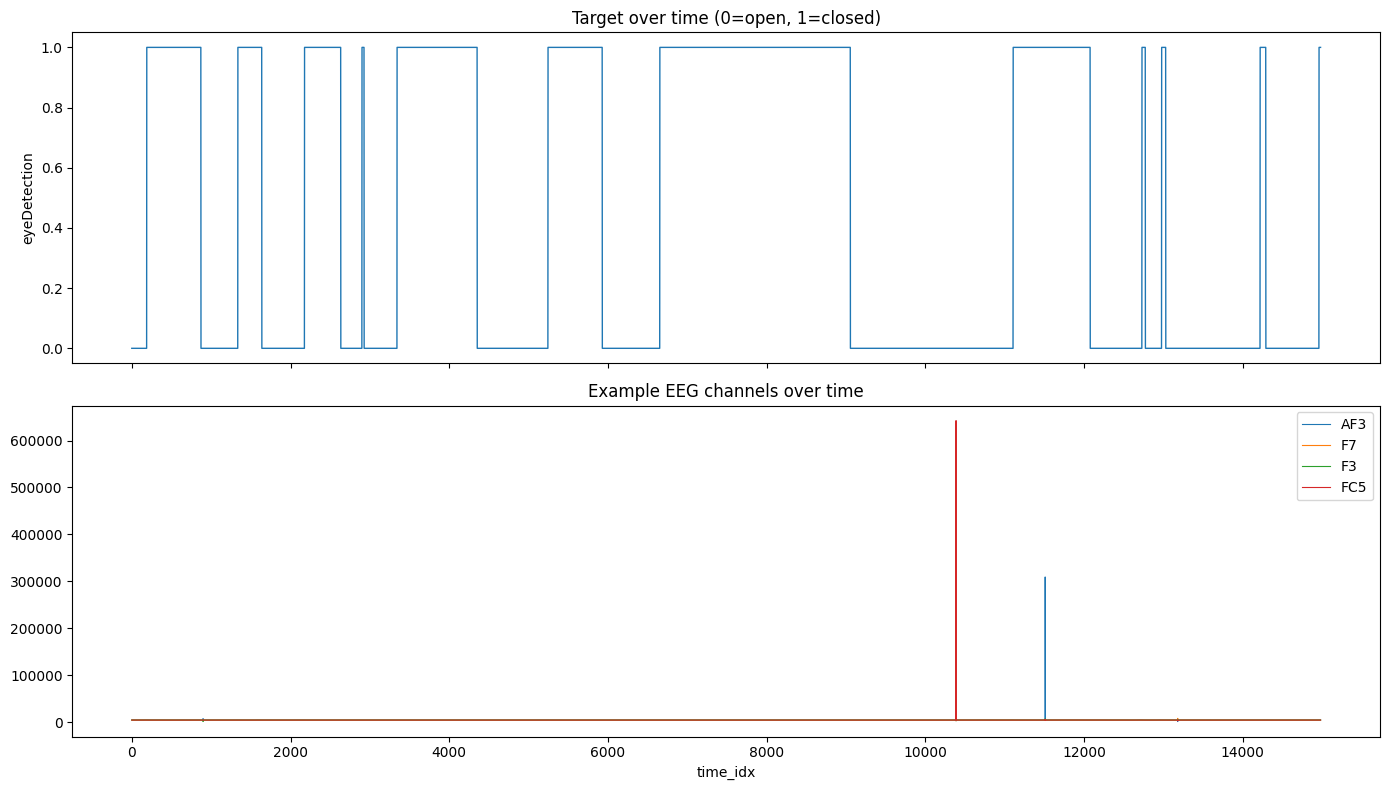

In [11]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["time_idx"], df[target_col], linewidth=1)
axes[0].set_title("Target over time (0=open, 1=closed)")
axes[0].set_ylabel(target_col)

sample_plot_cols = feature_cols[: min(4, len(feature_cols))]
for c in sample_plot_cols:
    axes[1].plot(df["time_idx"], df[c], label=c, linewidth=0.8)

axes[1].set_title("Example EEG channels over time")
axes[1].set_xlabel("time_idx")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()



## Strict chronological split

The **last 30% of the original dataset** is the test set.  
All tuning, feature selection, and threshold selection happen **only on the first 70%**.


In [12]:

n_total = len(df)
split_idx = int(n_total * 0.70)

train_raw = df.iloc[:split_idx].copy()
test_raw = df.iloc[split_idx:].copy()

print(f"Total rows      : {n_total}")
print(f"Train rows (70%): {len(train_raw)}")
print(f"Test rows (30%) : {len(test_raw)}")
print(f"Train last time_idx: {train_raw['time_idx'].iloc[-1]}")
print(f"Test first time_idx: {test_raw['time_idx'].iloc[0]}")


Total rows      : 14980
Train rows (70%): 10486
Test rows (30%) : 4494
Train last time_idx: 10485
Test first time_idx: 10486



## Leakage-safe feature engineering

Every feature below is **causal**:
- lags use past values only
- rolling windows are trailing windows only
- EWM uses past values only
- no centered windows
- no shuffling
- no target leakage

We build features on the full dataframe, but every transformation uses only current/past observations.  
That means the test features never access future information.


In [13]:

MAX_LAG = 32
ROLL_WINDOWS = [4, 8, 16, 32, 64]
HJORTH_WINDOWS = [32, 64]
EWM_SPANS = [4, 8, 16, 32]
PAIR_WINDOWS = [16, 64]
MAX_LOOKBACK = max(max(ROLL_WINDOWS), MAX_LAG)

LEFT_RIGHT_PAIRS = [
    ("AF3", "AF4"),
    ("F7", "F8"),
    ("F3", "F4"),
    ("FC5", "FC6"),
    ("T7", "T8"),
    ("P7", "P8"),
    ("O1", "O2"),
]

def add_channel_features(s: pd.Series, prefix: str) -> pd.DataFrame:
    out = pd.DataFrame(index=s.index)
    s = s.astype("float32")

    # Raw
    out[prefix] = s

    # Lags and lag-differences
    for lag in [1, 2, 4, 8, 16, 32]:
        lagged = s.shift(lag)
        out[f"{prefix}_lag_{lag}"] = lagged
        out[f"{prefix}_diff_{lag}"] = s - lagged

    # EWM summaries
    for span in EWM_SPANS:
        ewm_mean = s.ewm(span=span, adjust=False).mean()
        ewm_std = s.ewm(span=span, adjust=False).std()
        out[f"{prefix}_ewm_mean_{span}"] = ewm_mean
        out[f"{prefix}_ewm_std_{span}"] = ewm_std

    # Rolling EEG descriptors
    sq = s.pow(2)
    abs_diff = s.diff().abs()

    for w in ROLL_WINDOWS:
        roll = s.rolling(w, min_periods=w)
        out[f"{prefix}_rmean_{w}"] = roll.mean()
        out[f"{prefix}_rstd_{w}"] = roll.std()
        out[f"{prefix}_rmin_{w}"] = roll.min()
        out[f"{prefix}_rmax_{w}"] = roll.max()
        out[f"{prefix}_rmedian_{w}"] = roll.median()
        out[f"{prefix}_renergy_{w}"] = sq.rolling(w, min_periods=w).mean()
        out[f"{prefix}_line_length_{w}"] = abs_diff.rolling(w, min_periods=w).sum()

        mean_ = out[f"{prefix}_rmean_{w}"]
        std_ = out[f"{prefix}_rstd_{w}"]
        out[f"{prefix}_rz_{w}"] = (s - mean_) / (std_ + 1e-6)

    # Hjorth parameters (common EEG descriptors)
    dx = s.diff()
    ddx = dx.diff()
    for w in HJORTH_WINDOWS:
        var0 = s.rolling(w, min_periods=w).var()
        var1 = dx.rolling(w, min_periods=w).var()
        var2 = ddx.rolling(w, min_periods=w).var()

        activity = var0
        mobility = np.sqrt(var1 / (var0 + 1e-8))
        complexity = np.sqrt(var2 / (var1 + 1e-8)) / (mobility + 1e-8)

        out[f"{prefix}_hjorth_activity_{w}"] = activity
        out[f"{prefix}_hjorth_mobility_{w}"] = mobility
        out[f"{prefix}_hjorth_complexity_{w}"] = complexity

    return out

def make_temporal_features(df_in: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    blocks = []

    # Per-channel causal features
    for c in feature_cols:
        blocks.append(add_channel_features(df_in[c], c))

    X = pd.concat(blocks, axis=1)

    # Global cross-channel summaries at each timestamp
    raw = df_in[feature_cols].astype("float32")
    X["global_mean"] = raw.mean(axis=1)
    X["global_std"] = raw.std(axis=1)
    X["global_min"] = raw.min(axis=1)
    X["global_max"] = raw.max(axis=1)
    X["global_range"] = X["global_max"] - X["global_min"]
    X["global_energy"] = raw.pow(2).mean(axis=1)
    X["global_abs_mean"] = raw.abs().mean(axis=1)

    for w in [8, 16, 32, 64]:
        X[f"global_mean_rmean_{w}"] = X["global_mean"].rolling(w, min_periods=w).mean()
        X[f"global_std_rmean_{w}"] = X["global_std"].rolling(w, min_periods=w).mean()
        X[f"global_energy_rmean_{w}"] = X["global_energy"].rolling(w, min_periods=w).mean()

    # Inter-hemispheric asymmetry features where columns exist
    existing = set(feature_cols)
    for left, right in LEFT_RIGHT_PAIRS:
        if left in existing and right in existing:
            diff = raw[left] - raw[right]
            absdiff = diff.abs()
            summ = raw[left] + raw[right]

            X[f"{left}_{right}_diff"] = diff
            X[f"{left}_{right}_absdiff"] = absdiff
            X[f"{left}_{right}_sum"] = summ

            for w in PAIR_WINDOWS:
                X[f"{left}_{right}_diff_rmean_{w}"] = diff.rolling(w, min_periods=w).mean()
                X[f"{left}_{right}_diff_rstd_{w}"] = diff.rolling(w, min_periods=w).std()
                X[f"{left}_{right}_corr_{w}"] = raw[left].rolling(w, min_periods=w).corr(raw[right])

    return X

X_all = make_temporal_features(df, feature_cols)
y_all = df[target_col].copy()
time_idx_all = df["time_idx"].copy()

print("Feature matrix before warmup trimming:", X_all.shape)
display(X_all.head())


Feature matrix before warmup trimming: (14980, 1020)


,AF3,AF3_lag_1,AF3_diff_1,AF3_lag_2,AF3_diff_2,AF3_lag_4,AF3_diff_4,AF3_lag_8,AF3_diff_8,AF3_lag_16,AF3_diff_16,AF3_lag_32,AF3_diff_32,AF3_ewm_mean_4,AF3_ewm_std_4,AF3_ewm_mean_8,AF3_ewm_std_8,AF3_ewm_mean_16,AF3_ewm_std_16,AF3_ewm_mean_32,AF3_ewm_std_32,AF3_rmean_4,AF3_rstd_4,AF3_rmin_4,AF3_rmax_4,AF3_rmedian_4,AF3_renergy_4,AF3_line_length_4,AF3_rz_4,AF3_rmean_8,AF3_rstd_8,AF3_rmin_8,AF3_rmax_8,AF3_rmedian_8,AF3_renergy_8,AF3_line_length_8,AF3_rz_8,AF3_rmean_16,AF3_rstd_16,AF3_rmin_16,AF3_rmax_16,AF3_rmedian_16,AF3_renergy_16,AF3_line_length_16,AF3_rz_16,AF3_rmean_32,AF3_rstd_32,AF3_rmin_32,AF3_rmax_32,AF3_rmedian_32,AF3_renergy_32,AF3_line_length_32,AF3_rz_32,AF3_rmean_64,AF3_rstd_64,AF3_rmin_64,AF3_rmax_64,AF3_rmedian_64,AF3_renergy_64,AF3_line_length_64,AF3_rz_64,AF3_hjorth_activity_32,AF3_hjorth_mobility_32,AF3_hjorth_complexity_32,AF3_hjorth_activity_64,AF3_hjorth_mobility_64,AF3_hjorth_complexity_64,F7,F7_lag_1,F7_diff_1,F7_lag_2,F7_diff_2,F7_lag_4,F7_diff_4,F7_lag_8,F7_diff_8,F7_lag_16,F7_diff_16,F7_lag_32,F7_diff_32,F7_ewm_mean_4,F7_ewm_std_4,F7_ewm_mean_8,F7_ewm_std_8,F7_ewm_mean_16,F7_ewm_std_16,F7_ewm_mean_32,F7_ewm_std_32,F7_rmean_4,F7_rstd_4,F7_rmin_4,F7_rmax_4,F7_rmedian_4,F7_renergy_4,F7_line_length_4,F7_rz_4,F7_rmean_8,F7_rstd_8,F7_rmin_8,F7_rmax_8,...,AF4_rmedian_32,AF4_renergy_32,AF4_line_length_32,AF4_rz_32,AF4_rmean_64,AF4_rstd_64,AF4_rmin_64,AF4_rmax_64,AF4_rmedian_64,AF4_renergy_64,AF4_line_length_64,AF4_rz_64,AF4_hjorth_activity_32,AF4_hjorth_mobility_32,AF4_hjorth_complexity_32,AF4_hjorth_activity_64,AF4_hjorth_mobility_64,AF4_hjorth_complexity_64,global_mean,global_std,global_min,global_max,global_range,global_energy,global_abs_mean,global_mean_rmean_8,global_std_rmean_8,global_energy_rmean_8,global_mean_rmean_16,global_std_rmean_16,global_energy_rmean_16,global_mean_rmean_32,global_std_rmean_32,global_energy_rmean_32,global_mean_rmean_64,global_std_rmean_64,global_energy_rmean_64,AF3_AF4_diff,AF3_AF4_absdiff,AF3_AF4_sum,AF3_AF4_diff_rmean_16,AF3_AF4_diff_rstd_16,AF3_AF4_corr_16,AF3_AF4_diff_rmean_64,AF3_AF4_diff_rstd_64,AF3_AF4_corr_64,F7_F8_diff,F7_F8_absdiff,F7_F8_sum,F7_F8_diff_rmean_16,F7_F8_diff_rstd_16,F7_F8_corr_16,F7_F8_diff_rmean_64,F7_F8_diff_rstd_64,F7_F8_corr_64,F3_F4_diff,F3_F4_absdiff,F3_F4_sum,F3_F4_diff_rmean_16,F3_F4_diff_rstd_16,F3_F4_corr_16,F3_F4_diff_rmean_64,F3_F4_diff_rstd_64,F3_F4_corr_64,FC5_FC6_diff,FC5_FC6_absdiff,FC5_FC6_sum,FC5_FC6_diff_rmean_16,FC5_FC6_diff_rstd_16,FC5_FC6_corr_16,FC5_FC6_diff_rmean_64,FC5_FC6_diff_rstd_64,FC5_FC6_corr_64,T7_T8_diff,T7_T8_absdiff,T7_T8_sum,T7_T8_diff_rmean_16,T7_T8_diff_rstd_16,T7_T8_corr_16,T7_T8_diff_rmean_64,T7_T8_diff_rstd_64,T7_T8_corr_64,P7_P8_diff,P7_P8_absdiff,P7_P8_sum,P7_P8_diff_rmean_16,P7_P8_diff_rstd_16,P7_P8_corr_16,P7_P8_diff_rmean_64,P7_P8_diff_rstd_64,P7_P8_corr_64,O1_O2_diff,O1_O2_absdiff,O1_O2_sum,O1_O2_diff_rmean_16,O1_O2_diff_rstd_16,O1_O2_corr_16,O1_O2_diff_rmean_64,O1_O2_diff_rstd_64,O1_O2_corr_64
0,4329.229980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4329.229980,NaN,4329.229980,NaN,4329.229980,NaN,4329.229980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4009.229980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4009.229980,NaN,4009.229980,NaN,4009.229980,NaN,4009.229980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4316.593750,193.431519,4009.229980,4641.029785,631.799805,18667724.0,4316.593750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-64.620117,64.620117,8723.080078,NaN,NaN,NaN,NaN,NaN,NaN,-626.669922,626.669922,8645.129883,NaN,NaN,NaN,NaN,NaN,NaN,8.720215,8.720215,8569.740234,NaN,NaN,NaN,NaN,NaN,NaN,-63.069824,63.069824,8359.490234,NaN,NaN,NaN,NaN,NaN,NaN,111.799805,111.799805,8588.719727,NaN,NaN,NaN,NaN,NaN,NaN,364.100098,364.100098,8808.199219,NaN,NaN,NaN,NaN,NaN,NaN,-544.1

In [14]:

# Drop warmup rows that don't have enough history for the largest rolling windows
valid_mask = X_all.notna().all(axis=1)

X_all = X_all.loc[valid_mask].reset_index(drop=True)
y_all = y_all.loc[valid_mask].reset_index(drop=True)
time_idx_all = time_idx_all.loc[valid_mask].reset_index(drop=True)

print("Feature matrix after warmup trimming:", X_all.shape)
print("Earliest retained original time_idx:", time_idx_all.min())
print("Latest retained original time_idx:", time_idx_all.max())


Feature matrix after warmup trimming: (14915, 1020)
Earliest retained original time_idx: 65
Latest retained original time_idx: 14979


In [15]:

# Recreate the split using the ORIGINAL boundary: last 30% of the original dataset is test
train_mask = time_idx_all < split_idx
test_mask = time_idx_all >= split_idx

X_train = X_all.loc[train_mask].reset_index(drop=True)
y_train = y_all.loc[train_mask].reset_index(drop=True)

X_test = X_all.loc[test_mask].reset_index(drop=True)
y_test = y_all.loc[test_mask].reset_index(drop=True)

print("Train feature shape:", X_train.shape)
print("Test feature shape :", X_test.shape)

assert X_train.index.max() < len(X_train)
assert X_test.index.max() < len(X_test)
assert (time_idx_all.loc[train_mask].max() < split_idx)
assert (time_idx_all.loc[test_mask].min() >= split_idx)


Train feature shape: (10421, 1020)
Test feature shape : (4494, 1020)



## Model tuning with purged walk-forward cross-validation

We use:
- `TimeSeriesSplit`
- `gap=MAX_LOOKBACK` to create an embargo around fold boundaries
- aggressive XGBoost regularization
- early stopping inside each fold
- optimization target = **mean validation log loss**


In [16]:

import xgboost as xgb
import optuna

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_estimators": 4000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 4, 20),
        "subsample": trial.suggest_float("subsample", 0.55, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.35, 0.8),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 40.0, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 5),
        "early_stopping_rounds": 150,
    }

    splitter = TimeSeriesSplit(n_splits=5, gap=MAX_LOOKBACK)
    fold_losses = []
    best_iters = []

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        prob_val = model.predict_proba(X_val)[:, 1]
        loss = log_loss(y_val, prob_val, labels=[0, 1])
        fold_losses.append(loss)

        best_iter = getattr(model, "best_iteration", None)
        if best_iter is None:
            best_iter = params["n_estimators"]
        best_iters.append(int(best_iter))

    trial.set_user_attr("median_best_iteration", int(np.median(best_iters)))
    return float(np.mean(fold_losses))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_trial.params.copy()
best_n_estimators = study.best_trial.user_attrs["median_best_iteration"]

print("Best CV logloss:", study.best_value)
print("Best params:", best_params)
print("Median best iteration:", best_n_estimators)


[I 2026-04-10 10:39:07,536] A new study created in memory with name: no-name-031fbf04-462f-4fdd-8020-cace9fb271a5
Best trial: 0. Best value: 0.62758:   3%|▎         | 1/30 [01:21<39:33, 81.84s/it]

[I 2026-04-10 10:40:29,372] Trial 0 finished with value: 0.6275799455696233 and parameters: {'learning_rate': 0.029961038435364146, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.811961519390864, 'colsample_bytree': 0.468013486439283, 'gamma': 1.8615207851814337, 'reg_alpha': 0.011078077811035635, 'reg_lambda': 8.716245198694056, 'max_delta_step': 0}. Best is trial 0 with value: 0.6275799455696233.


Best trial: 1. Best value: 0.61879:   7%|▋         | 2/30 [02:50<40:05, 85.92s/it]

[I 2026-04-10 10:41:58,147] Trial 1 finished with value: 0.6187900135014808 and parameters: {'learning_rate': 0.0120017429434019, 'max_depth': 3, 'min_child_weight': 4, 'subsample': 0.7782367219391749, 'colsample_bytree': 0.5071884928320263, 'gamma': 1.5840341130683122, 'reg_alpha': 0.0018922002235246503, 'reg_lambda': 1.5038821596818903, 'max_delta_step': 3}. Best is trial 1 with value: 0.6187900135014808.


Best trial: 1. Best value: 0.61879:  10%|█         | 3/30 [05:06<48:55, 108.71s/it]

...

[I 2026-04-10 11:32:35,188] Trial 27 finished with value: 0.6126064310648054 and parameters: {'learning_rate': 0.01577952639312111, 'max_depth': 3, 'min_child_weight': 17, 'subsample': 0.6273081161771822, 'colsample_bytree': 0.6215700625252338, 'gamma': 1.265736316853041, 'reg_alpha': 0.004060381493443234, 'reg_lambda': 11.847047953843273, 'max_delta_step': 4}. Best is trial 22 with value: 0.6089023193561275.


Best trial: 22. Best value: 0.608902:  97%|█████████▋| 29/30 [56:24<02:41, 161.06s/it]

[I 2026-04-10 11:35:32,363] Trial 28 finished with value: 0.6171874561002181 and parameters: {'learning_rate': 0.013550645462298174, 'max_depth': 4, 'min_child_weight': 13, 'subsample': 0.7655289244685559, 'colsample_bytree': 0.5626686001319133, 'gamma': 0.842310617849412, 'reg_alpha': 0.03458098353812916, 'reg_lambda': 5.159725515624322, 'max_delta_step': 2}. Best is trial 22 with value: 0.6089023193561275.


Best trial: 22. Best value: 0.608902: 100%|██████████| 30/30 [1:00:17<00:00, 120.57s/it]

[I 2026-04-10 11:39:24,755] Trial 29 finished with value: 0.6189816184852217 and parameters: {'learning_rate': 0.01149922462735977, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.668459888870762, 'colsample_bytree': 0.7419667155654605, 'gamma': 0.5576674236934712, 'reg_alpha': 0.011433803815167351, 'reg_lambda': 8.452518912308726, 'max_delta_step': 3}. Best is trial 22 with value: 0.6089023193561275.
Best CV logloss: 0.6089023193561275
Best params: {'learning_rate': 0.01488305302281751, 'max_depth': 4, 'min_child_weight': 17, 'subsample': 0.6779489838090293, 'colsample_bytree': 0.6444835175931576, 'gamma': 0.3643056763235455, 'reg_alpha': 0.040438511331356355, 'reg_lambda': 7.544242867056659, 'max_delta_step': 2}
Median best iteration: 49



## Stability-based feature selection

Even with strong regularization, an aggressively engineered feature set can still overfit.  
To reduce that risk, we keep only features that remain important across multiple temporal folds.


In [17]:

final_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_estimators": int(best_n_estimators),
    "learning_rate": best_params["learning_rate"],
    "max_depth": int(best_params["max_depth"]),
    "min_child_weight": int(best_params["min_child_weight"]),
    "subsample": best_params["subsample"],
    "colsample_bytree": best_params["colsample_bytree"],
    "gamma": best_params["gamma"],
    "reg_alpha": best_params["reg_alpha"],
    "reg_lambda": best_params["reg_lambda"],
    "max_delta_step": int(best_params["max_delta_step"]),
}

def stable_feature_selection(X, y, params, n_splits=5, top_k=120, min_fold_fraction=0.6):
    splitter = TimeSeriesSplit(n_splits=n_splits, gap=MAX_LOOKBACK)
    fold_counter = Counter()
    all_importances = []

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        fi = pd.Series(model.feature_importances_, index=X.columns)
        fi = fi.sort_values(ascending=False)
        all_importances.append(fi.rename(f"fold_{fold}"))

        for feat in fi.head(top_k).index:
            fold_counter[feat] += 1

    need_count = math.ceil(n_splits * min_fold_fraction)
    stable_feats = [f for f, c in fold_counter.items() if c >= need_count]

    imp_df = pd.concat(all_importances, axis=1).fillna(0.0)
    imp_df["mean_importance"] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values("mean_importance", ascending=False)

    if len(stable_feats) < 30:
        stable_feats = imp_df.head(60).index.tolist()

    stable_feats = [f for f in imp_df.index if f in set(stable_feats)]
    return stable_feats, imp_df

stable_features, importance_df = stable_feature_selection(
    X_train, y_train, final_params, n_splits=5, top_k=120, min_fold_fraction=0.6
)

print("Selected stable features:", len(stable_features))
display(importance_df.head(20))


Selected stable features: 69


,fold_1,fold_2,fold_3,fold_4,fold_5,mean_importance
F4_renergy_64,0.097819,0.067321,0.000000,0.000000,0.000000,0.033028
F4_rmean_64,0.095295,0.052265,0.000000,0.002928,0.000000,0.030098
F8_rmax_64,0.095703,0.013855,0.012633,0.012659,0.008899,0.028750
F8_rmedian_64,0.000000,0.045816,0.037762,0.025459,0.004242,0.022656
AF4_rmedian_64,0.062513,0.006765,0.008729,0.017980,0.006929,0.020583
F4_rmedian_64,0.040946,0.056236,0.000000,0.004568,0.000000,0.020350
O1_rmedian_64,0.000000,0.018089,0.036245,0.023037,0.012220,0.017918
F8_rmin_64,0.000000,0.000000,0.042155,0.024495,0.022853,0.017901
F8_rmean_64,0.000000,0.002097,0.047305,0.030360,0.008290,0.017610
FC5_FC6_diff_rmean_64,0.041838,0.013529,0.014680,0.006378,0.005737,0.016433


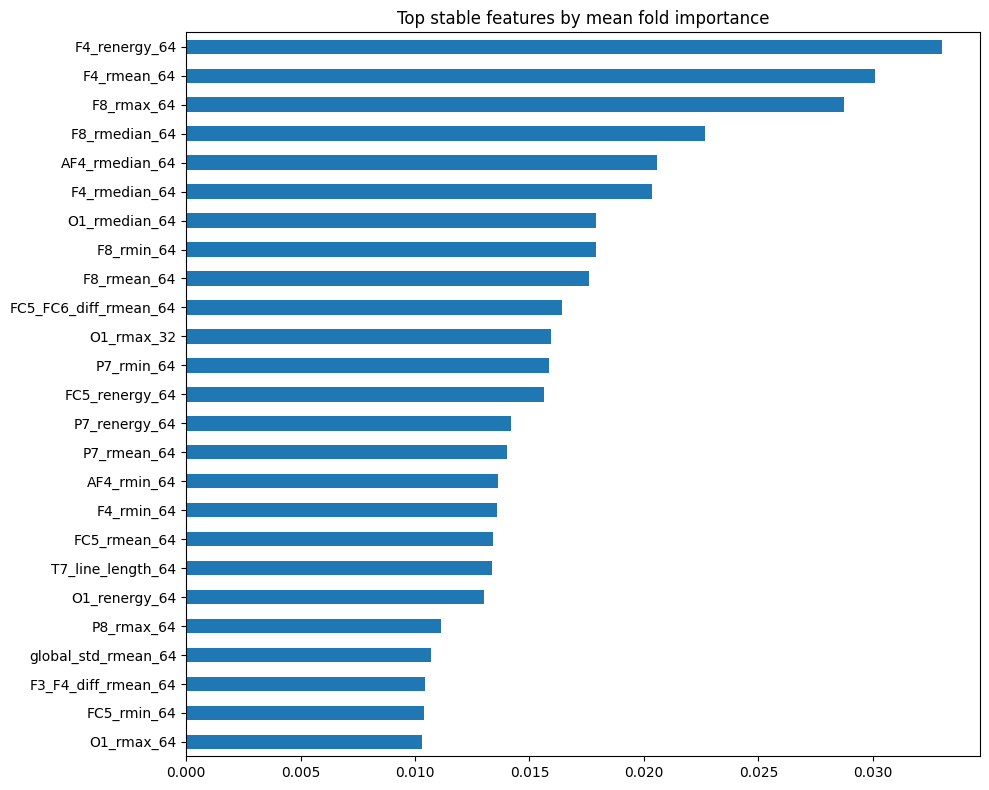

In [18]:

plt.figure(figsize=(10, 8))
importance_df.head(25)["mean_importance"].sort_values().plot(kind="barh")
plt.title("Top stable features by mean fold importance")
plt.tight_layout()
plt.show()



## Out-of-fold probabilities for threshold tuning

We choose the classification threshold using **only training-period out-of-fold predictions**.  
This avoids touching the held-out test set.


In [19]:

def temporal_oof_probabilities(X, y, feature_list, params, n_splits=5):
    splitter = TimeSeriesSplit(n_splits=n_splits, gap=MAX_LOOKBACK)
    oof = pd.Series(index=np.arange(len(X)), dtype="float64")

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X), start=1):
        X_tr, X_val = X.iloc[tr_idx][feature_list], X.iloc[val_idx][feature_list]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        oof.iloc[val_idx] = model.predict_proba(X_val)[:, 1]

    return oof

oof_prob = temporal_oof_probabilities(X_train, y_train, stable_features, final_params, n_splits=5)
valid_oof = oof_prob.notna()

threshold_grid = np.linspace(0.20, 0.80, 121)
scores = []

for t in threshold_grid:
    pred = (oof_prob[valid_oof] >= t).astype(int)
    mcc = matthews_corrcoef(y_train[valid_oof], pred)
    bal_acc = balanced_accuracy_score(y_train[valid_oof], pred)
    scores.append((t, mcc, bal_acc))

threshold_df = pd.DataFrame(scores, columns=["threshold", "mcc", "balanced_accuracy"])
best_threshold = threshold_df.sort_values(["mcc", "balanced_accuracy"], ascending=False).iloc[0]["threshold"]

print("Best threshold from training OOF:", best_threshold)
display(threshold_df.sort_values(["mcc", "balanced_accuracy"], ascending=False).head(10))


Best threshold from training OOF: 0.5650000000000001


,threshold,mcc,balanced_accuracy
73,0.565,0.261405,0.630245
70,0.550,0.261012,0.629693
74,0.570,0.260772,0.630050
72,0.560,0.260032,0.629457
75,0.575,0.258249,0.628880
76,0.580,0.257325,0.628599
71,0.555,0.256824,0.627758
69,0.545,0.256777,0.627365
77,0.585,0.255106,0.627692
78,0.590,0.254072,0.627229


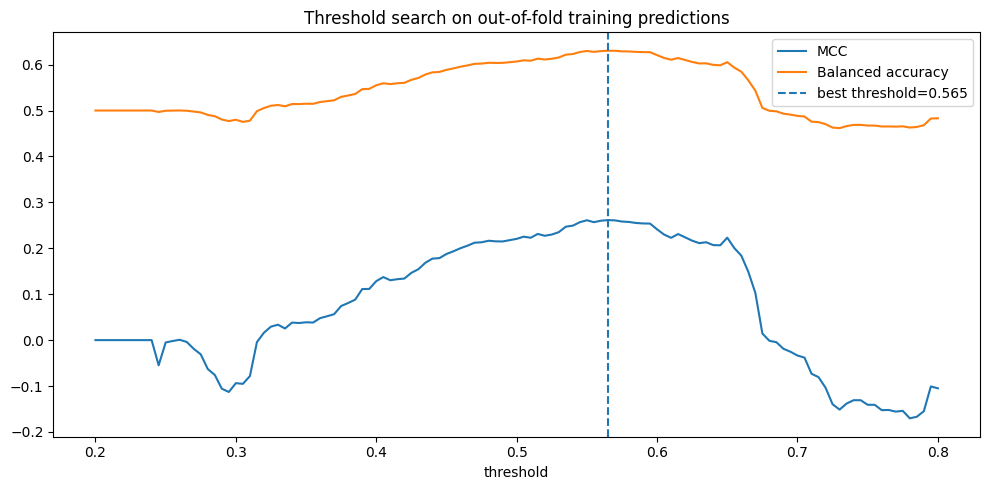

In [20]:

plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["mcc"], label="MCC")
plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], label="Balanced accuracy")
plt.axvline(best_threshold, linestyle="--", label=f"best threshold={best_threshold:.3f}")
plt.title("Threshold search on out-of-fold training predictions")
plt.xlabel("threshold")
plt.legend()
plt.tight_layout()
plt.show()



## Final model fit on the full training period

We now train once on the **entire first 70%** and evaluate exactly once on the **last 30%**.


In [21]:

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train[stable_features], y_train, verbose=False)

test_prob = final_model.predict_proba(X_test[stable_features])[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_prob),
    "pr_auc": average_precision_score(y_test, test_prob),
    "log_loss": log_loss(y_test, test_prob, labels=[0, 1]),
    "mcc": matthews_corrcoef(y_test, test_pred),
}

metrics_df = pd.DataFrame(metrics, index=["test"]).T.rename(columns={"test": "value"})
display(metrics_df)


,value
accuracy,0.538496
balanced_accuracy,0.561263
roc_auc,0.611936
pr_auc,0.431628
log_loss,0.742048
mcc,0.107269


In [22]:

print("Classification report on the untouched last-30% test set:")
print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
display(cm_df)


Classification report on the untouched last-30% test set:
              precision    recall  f1-score   support

           0     0.7907    0.5142    0.6232      3335
           1     0.3032    0.6083    0.4047      1159

    accuracy                         0.5385      4494
   macro avg     0.5470    0.5613    0.5139      4494
weighted avg     0.6650    0.5385    0.5668      4494



,pred_0,pred_1
true_0,1715,1620
true_1,454,705


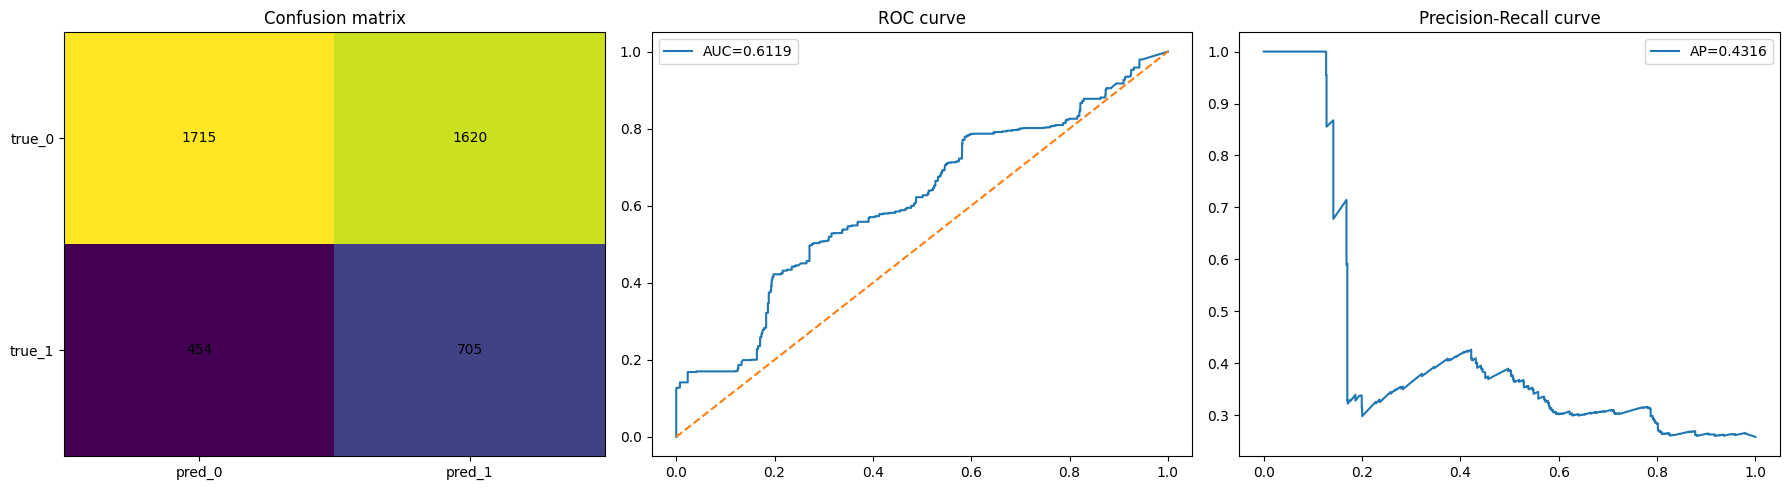

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm, aspect="auto")
axes[0].set_title("Confusion matrix")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["pred_0", "pred_1"])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["true_0", "true_1"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center")

# ROC
fpr, tpr, _ = roc_curve(y_test, test_prob)
axes[1].plot(fpr, tpr, label=f"AUC={metrics['roc_auc']:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("ROC curve")
axes[1].legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, test_prob)
axes[2].plot(rec, prec, label=f"AP={metrics['pr_auc']:.4f}")
axes[2].set_title("Precision-Recall curve")
axes[2].legend()

plt.tight_layout()
plt.show()



## Prediction timeline on the test period

This makes it easier to see where the model tracks transitions well and where it lags or produces isolated errors.


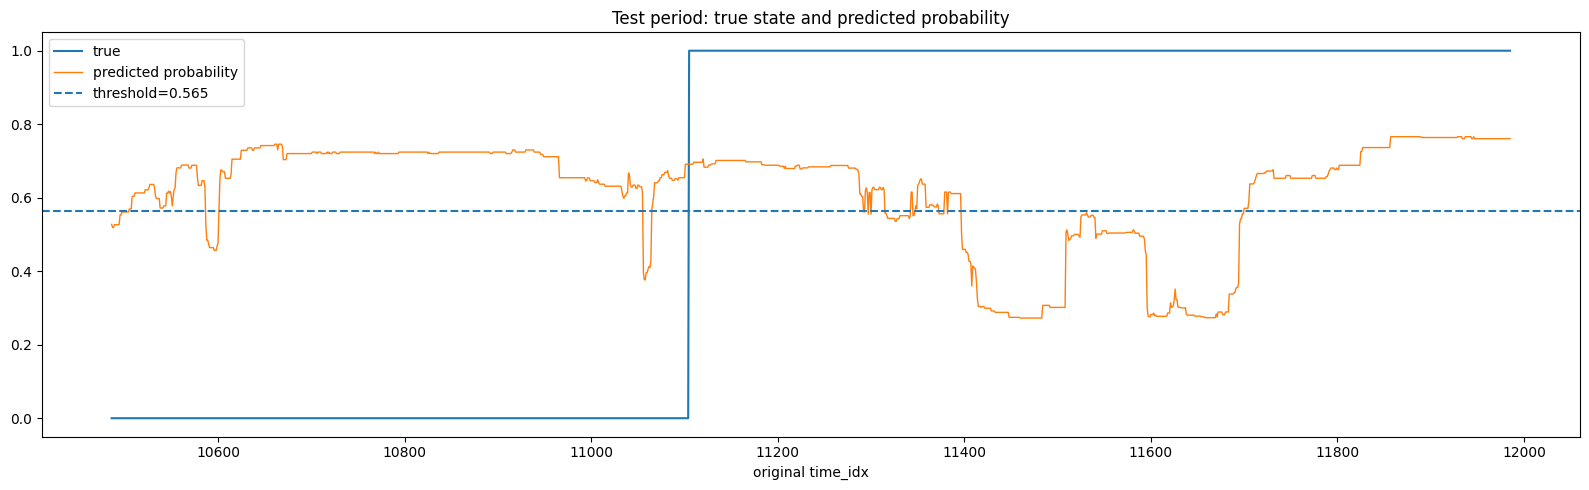

In [24]:

test_time = time_idx_all.loc[test_mask].reset_index(drop=True)

plot_n = min(len(test_time), 1500)
plt.figure(figsize=(16, 5))
plt.plot(test_time.iloc[:plot_n], y_test.iloc[:plot_n].values, label="true", linewidth=1.5)
plt.plot(test_time.iloc[:plot_n], test_prob[:plot_n], label="predicted probability", linewidth=1.0)
plt.axhline(best_threshold, linestyle="--", label=f"threshold={best_threshold:.3f}")
plt.title("Test period: true state and predicted probability")
plt.xlabel("original time_idx")
plt.legend()
plt.tight_layout()
plt.show()



## Interpretation

SHAP is optional here. It helps identify which temporal summaries and asymmetry features drive the model.


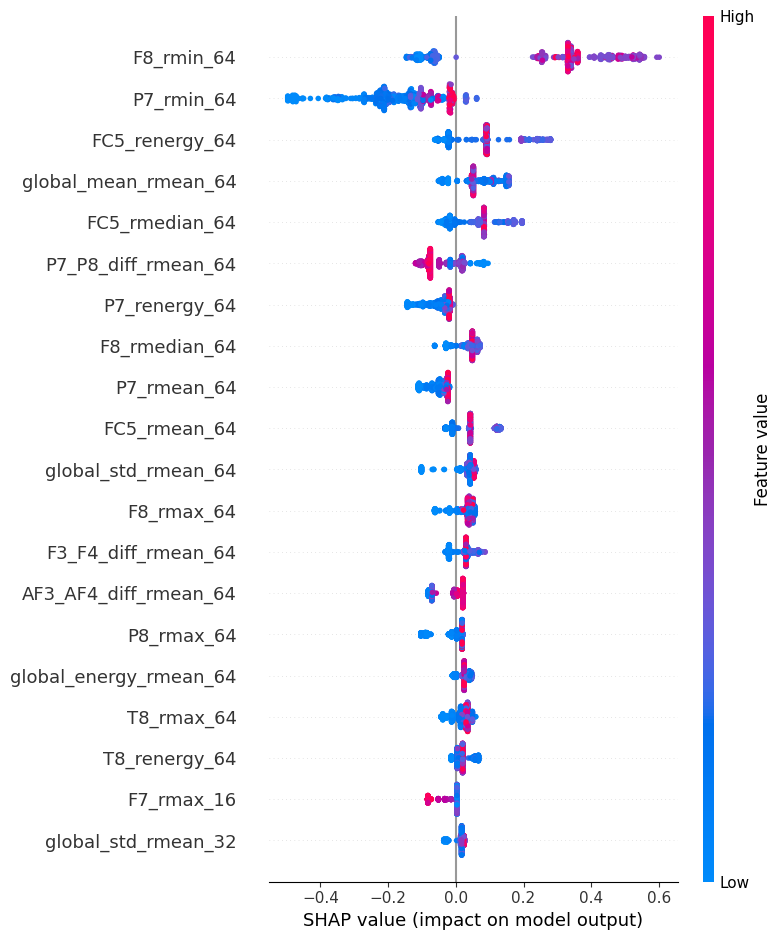

In [25]:

# Optional SHAP analysis
try:
    import shap

    sample_n = min(1000, len(X_test))
    X_shap = X_test[stable_features].iloc[:sample_n]

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP skipped:", e)



## What to do next

1. Compare this model against a **simpler baseline**:
   - logistic regression on only raw features
   - random forest without temporal features
2. Try a **causal smoothing layer** over predicted probabilities using only past predictions.
3. If you have more EEG sessions, move to a **session-aware evaluation** so the test period comes from a different session or subject.
4. For publication-grade work, add:
   - nested temporal CV
   - permutation importance over time blocks
   - confidence calibration analysis



## Summary

This notebook is intentionally conservative:
- chronological integrity is preserved
- the final test set is the last 30%
- all engineered features are causal
- hyperparameter tuning, feature selection, and threshold tuning happen only on the training period
- regularization and stability filtering are used to reduce overfitting risk

That does **not** guarantee zero overfitting—nothing can—but it is a strong, leakage-resistant setup for this dataset.
